# 過分散のあるポアソン分布モデル（負の二項分布モデル）

工業製品のロットあたりの不良品数や時間あたりの故障発生数、野球の安打数のような**計数データ**（count data）をモデリングするには、対象とする現象に応じて以下のように二項分布・ポアソン分布を使い分けます。

|確率分布名|モデリング対象の現象|例|
|---|---|---|
|二項分布|$n$回試行した際の発生数$x$|ロットあたり不良品数、野球の安打数|
|ポアソン分布|面積・時間$t$あたりの発生数$x$|機械の時間あたり故障発生数、面積あたり雑草発生数|

このような**二項分布、ポアソン分布を用いた計数データのモデリング**は、現象の**発生確率**（二項分布では成功確率パラメータ$\mu$、ポアソン分布では単位区間あたり平均発生数パラメータ$\mu$）**が一定であることを前提**としています。
発生確率が一定でない場合、以下の図に示すようにデータのばらつきが二項分布・ポアソン分布が予測するよりも大きくなる、**過分散**（overdispersion）と呼ばれる現象が発生します。

過分散が発生している場合、二項分布・ポアソン分布をそのまま使用すると、データの挙動を精度よくモデリングすることができません。代わりに以下のようにベータ二項分布、負の二項分布を用いることで、過分散を考慮したモデリングを実現できます。

- 過分散を含む二項分布：**ベータ二項分布**
- 過分散を含むポアソン分布：**負の二項分布**

ここでは負の二項分布を用いることで過分散を考慮して、面積・時間$t$あたりの発生数$x$に異常検知を適用する方法を解説します。

## 負の二項分布モデルによる異常検知の実装

　[こちらの学習手順、推論手順]()に基づいた異常検知を、Pythonで実装してみます。

今回はモデリングの対象として、書籍の5章でも使用した都道府県ごとの面積あたり活火山数データ[^volcanoes]を使用します。

```csv
region,prefecture,volcanoes,area
Hokkaido,Hokkaido,20,8.342
Tohoku,Aomori,4,0.965
Tohoku,Akita,2,1.164
Tohoku,Iwate,3,1.528
...
Kyushu,Kumamoto,1,0.741
Kyushu,Miyazaki,0,0.774
Kyushu,Kagoshima,11,0.919
Kyushu,Okinawa,1,0.228
```

`region`列が地方（今回は使用しない）、`prefecture`列が都道府県、`volcanoes`列が活火山数$x$、`area`列が都道府県の面積$t$（単位：万$km^2$）を表しています。北海道、東北、関東、中部地方を学習データ、それ以外の地方を推論データとして用います。

過分散を考慮しないポアソン分布モデルでは、「平均よりも偶然の範囲を超えて活火山の密度が高い都道府県」の検出を目的としていましたが、過分散を考慮する負の二項分布モデルでは、「**都道府県間の活火山数の差を考慮した上で、偶然の範囲を超えて活火山の密度が高い都道府県**」を検出することができます。

[^volcanoes]:https://www.data.jma.go.jp/vois/data/tokyo/STOCK/souran/main/kakkazanrisut.pdf

### 過分散判定

まず過分散の有無を判定し、ポアソン分布モデル（過分散なし）と負の二項分布モデル（過分散あり）のどちらを用いるかを判断します。

ポアソン分布モデルの過分散の判定には、以下の2種類の方法がよく用いられます。

- **ピアソンのカイ二乗統計量と自由度の比率**（[二項分布の過分散判定](https://github.com/ghmagazine/python_anomaly_detection_book/blob/main/notebooks/appendix/ch5_3_Beta_Binomial.ipynb)と同様）
- **Cameron and Trivedi’s test**[^cameron_trivedi]

それぞれ解説します。

#### ピアソンのカイ二乗統計量による過分散判定

In [1]:
# コード 8.201 | ポアソン分布モデルの過分散の判定（ピアソンのカイ二乗統計量）
import pandas as pd
import numpy as np

###### 学習データの読込と前処理 ######
# 日本の活火山データ
df = pd.read_csv("https://raw.githubusercontent.com/ghmagazine/python_anomaly_detection_book/refs/heads/main/notebooks/datasets/volcano_prefectures.csv")
df_train = df[df["region"].isin(['Hokkaido','Tohoku','Kanto','Chubu'])] # 対象地域を絞る
t_train = df_train["area"].to_numpy() # 面積t
x_train = df_train["volcanoes"].to_numpy() # 活火山の数x

###### ピアソンのカイ二乗統計量を用いて過分散の有無を判定 ######
mu = np.sum(x_train) / np.sum(t_train)  # 単位区間あたり平均発生数μの最尤推定量
chi2 = np.sum((x_train - t_train * mu) ** 2 / (t_train * mu))  # ピアソンのカイ二乗統計量
dfree = len(x_train) - 1  # 自由度
overdispersion_ratio = chi2 / dfree  # 過分散比D
print(f'ピアソンのカイ二乗統計量: {chi2:.2f}')
print(f'自由度: {dfree}')
print(f'過分散比 D: {overdispersion_ratio:.2f}')

ピアソンのカイ二乗統計量: 340.47
自由度: 22
過分散比 D: 15.48


ここでは過分散比Dのしきい値として、よく用いられる1.5を用います。Dが1.5を大幅に上回っているので、過分散ありとみなして負の二項分布モデルを用いることとします。

#### Cameron and Trivedi’s testによる過分散判定

[Cameron and Trivedi’s test]()による過分散判定を以下のように実装します。

In [2]:
# Cameron and Trivedi’s testを用いて過分散の有無を判定
import statsmodels.api as sm
from scipy import stats

# 線形回帰の説明変数として使用する変数λ_i
lambda_ct = t_train * mu
# 線形回帰の目的変数として使用する統計量z_i = ((x_i - λ_i)**2 - x_i) / λ_i
z_ct = ((x_train - lambda_ct) ** 2 - x_train) / lambda_ct
# 線形回帰の実行
mod = sm.OLS(z_ct, lambda_ct)
res = mod.fit(cov_type='HC1')
# 過分散の有無を判定
alpha_hat = res.params[0]
se_alpha = res.bse[0]
z_value = alpha_hat / se_alpha
p_value = 1 - stats.norm.cdf(z_value)  # 右片側
print(f"Cameron and Trivedi’s test: z = {z_value:.2f}, p-value = {p_value:.4f}")

Cameron and Trivedi’s test: z = 0.71, p-value = 0.2382


P値は0.2382と有意水準0.01よりも大きく、Cameron and Trivedi’s testの帰無仮説は棄却されません。よって「過分散は統計的に有意とは言えない」と結論づけられます。

ピアソン統計量の過分散比が非常に大きな値（15.48）となっているにも関わらず、Cameron and Trivedi’s testでは差がありません。これは

- 後述する学習データ中の外れ値（東京都のデータ）の影響で、ピアソン統計量の過分散比が非常に大きな値となった
- 一方でこの外れ値以外の過分散は大きくない上に、サンプルサイズも小さいため、Cameron and Trivedi’s testでは優位差ありとの結論が出なかった

という両手法の特性の違いが寄与したと思います。後述するように過分散の判定やモデリングは外れ値の影響を強く受けるため、外れ値の扱いには注意が必要です。

またCameron and Trivedi’s testのようなサンプルサイズに依存する仮説検定は、一般的にサンプルサイズが大きくなるほど優位差ありとの結論が出やすくなります（サンプルサイズが大きくなると、微小な真の差を検出するようになる）。よって今回のケースとは逆にサンプルサイズが大きい場合は、Cameron and Trivedi’s testの結果を基に負の二項分布モデルを採用することには慎重になるべきです。

上記のような問題はありますが、今回は便宜上、過分散があるという前提で実装を進めていきます。

### 学習

　学習フェーズでは、最尤推定による確率分布パラメータの推定を実施します。

SciPyにはベータ二項分布を実装するためのクラス`scipy.stats.nbinom`が用意されていますが、残念ながら最尤推定を実行するための`fit`メソッドが準備されていません。よってまずは以下のように、SciPyの数値最適化用メソッド`scipy.optimize.minimize`関数を用いて、最尤推定を実行する関数を実装します。

In [3]:
# コード 8.202 | 負の二項分布モデルの最尤推定を実行する関数
import numpy as np
from scipy.stats import nbinom
from scipy.optimize import minimize

def nbinom_neg_log_likelihood(params, x, t):
    """負の二項分布モデルの負の対数尤度を計算する関数（数値最適化の目的関数）"""
    k, theta = params
    # パラメータk,thetaは正の値でなければならない
    if k <= 0 or theta <= 0:
        return np.inf
    # 負の二項分布のパラメータpを計算
    p = 1.0 / (1.0 + theta * t)
    # 確率質量関数の対数の和（データ全体の対数尤度）を計算
    log_pmf_sum = nbinom.logpmf(x, n=k, p=p).sum()
    # 負の対数尤度を返す
    return -log_pmf_sum

def nbinom_mle(x, t, initial_params=(10.0, 0.1)):
    """負の二項分布モデルの最尤推定を実行する関数"""
    result = minimize(
        nbinom_neg_log_likelihood,
        initial_params,
        args=(x, t),
        method='L-BFGS-B',  # 数値最適化のアルゴリズム（L-BFGS-B）
        bounds=[(1e-5, None), (1e-5, None)]  # パラメータk,thetaは正の値
    )
    if result.success:
        return result.x  # 最適化されたパラメータk,thetaを返す
    else:
        raise RuntimeError("最尤推定が収束しませんでした。")

この関数を用いて、学習データを読み込んで最尤推定を実施します。

In [4]:
# コード 8.203 | 負の二項分布の最尤推定による異常検知の実装例（学習）
import pandas as pd

###### 学習データの読込と前処理 ######
# 日本の活火山データ
df = pd.read_csv("https://raw.githubusercontent.com/ghmagazine/python_anomaly_detection_book/refs/heads/main/notebooks/datasets/volcano_prefectures.csv")
df_train = df[df["region"].isin(['Hokkaido','Tohoku','Kanto','Chubu'])] # 対象地域を絞る
t_train = df_train["area"].to_numpy() # 面積t
x_train = df_train["volcanoes"].to_numpy() # 活火山の数x

###### 学習ステップ1. 正常のモデルを作成する ######
# 初期値設定
k0 = 10.0  # そこそこ大きめの k（Poisson に近い）
mu = np.sum(x_train) / np.sum(t_train)  # 単位区間あたり平均発生数μの最尤推定量
theta0 = mu / k0   # k * theta ≈ mu を満たすように調整
initial_params = (k0, theta0)
# 負の二項分布モデルの最尤推定を実行
k, theta = nbinom_mle(x_train, t_train, initial_params=initial_params)

###### 学習ステップ2. 異常を表す指標（異常度）を定義する ######
# 式を定義するのみでプログラム上は処理を実施しない

###### 学習ステップ3. 異常度にしきい値を設ける ######
# 推論時に都度算出するので、学習時はしきい値を求めない

###### 学習で求めたパラメータを表示 ######
print(f"k={k}, theta={theta}")

k=0.7321806091721106, theta=5.700687827503487


推定したパラメータ$\hat{k},\hat{\theta}$に基づき、単位区間あたり平均発生数$\mu$が従うガンマ分布を可視化してみます。

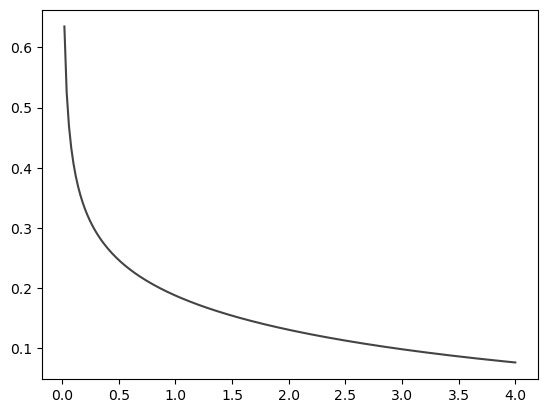

In [5]:
# コード 8.204 | ガンマ分布の確率密度関数を描画
from scipy import stats
import matplotlib.pyplot as plt

x = np.linspace(0, 4, 200)  # x軸の値（0から4まで200点）
y = stats.gamma.pdf(x, a=k, scale=theta)  # ガンマ分布の確率密度関数
plt.plot(x, y, label=fr'$k$={k}, $\theta$={theta}', # グラフ描画
         color='#444444')

$\mu$がある広がりをもった分布に従っていることが分かります。この広がりが過分散であり、今回のケースでは都道府県ごとの活火山密度の差に相当します。このような過分散を考慮したモデルを使用して異常検知を実施することで、ポアソン分布のばらつきだけでなく、都道府県ごとの密度のばらつきの範囲を超えて活火山の数が多い都道府県を検出することができます。

## B. 推論

学習フェーズで推定したパラメータ$\hat{k},\hat{\theta}$と推論データの観測区間$t$を用いて、負の二項分布モデルに基づく以下の式を用いて上下のしきい値$x_{thh},x_{thl}$を求めます。

$x_{thh} = NB_{CDF}^{-1}(1-0.00135 \mid \hat{k},\frac{1}{1+\hat{\theta}t})$

$x_{thl} = NB_{CDF}^{-1}(0.00135 \mid \hat{k},\frac{1}{1+\hat{\theta}t})$

ここで、$NB_{CDF}^{-1}$は負の二項分布の累積分布関数の逆関数を表し、$0.00135$はターゲットとする誤報率$0.0027\div 2$（両側判定なので2で割る必要がある）を表します。

このしきい値を用いて、以下のコードで推論データの都道府県ごと活火山数$x$に対して異常判定を行います。

In [6]:
# コード 8.103 | 負の二項分布の最尤推定による異常検知の実装例（推論）
from scipy import stats

###### 学習したパラメータをここに記載
K = k  # パラメータk
THETA = theta    # パラメータtheta

###### 推論データの読み込みと前処理######
# 日本の活火山データ
df = pd.read_csv("https://raw.githubusercontent.com/ghmagazine/python_anomaly_detection_book/refs/heads/main/notebooks/datasets/volcano_prefectures.csv")
df_inference = df[~df["region"].isin(['Hokkaido','Tohoku','Kanto','Chubu'])].copy() # 対象地域を絞る
t_inference = df_inference["area"].to_numpy() # 面積t
x_inference = df_inference["volcanoes"].to_numpy() # 活火山の数x

###### 推論を実行######
TARGET_FP_RATE = 0.0027 # ターゲットとする誤報率（正規分布の3σ相当=0.0027）
# 下側しきい値（負の二項分布の累積分布関数から計算）
th_lowers = stats.nbinom.ppf(TARGET_FP_RATE/2, n=K, p=1/(1+THETA*t_inference))
# 上側しきい値（負の二項分布の累積分布関数から計算）
th_uppers = stats.nbinom.ppf(1 - TARGET_FP_RATE/2, n=K, p=1/(1+THETA*t_inference))
# しきい値により異常の有無を判定
pred = np.where((x_inference < th_lowers) | (x_inference > th_uppers),
                "anomaly", "normal")

判定のしきい値を超えた都道府県の一覧をリストアップします。

In [7]:
# 推論結果を表示（しきい値を超えた都道府県）
df_inference["volcanoes / area"] = x_inference / t_inference # 面積あたり発生数
df_inference["prediction"] = pred
print(df_inference[df_inference["prediction"] == "anomaly"][
      ["prefecture", "volcanoes / area", "volcanoes", "area"]].sort_values(
      "volcanoes / area", ascending=False).reset_index(drop=True))

Empty DataFrame
Columns: [prefecture, volcanoes / area, volcanoes, area]
Index: []


今回は推論データのどの都道府県も検出されませんでした。

推論の結果、異常と判定される範囲を推論データと重ねて可視化してみます。

/var/folders/9f/r2qdz_xx5cb0t0vdjxq090kh0000gn/T/ipykernel_31771/2619235926.py:28: UserWarning: The palette list has more values (2) than needed (1), which may not be intended.
  sns.scatterplot(df_inference, x='area', y='volcanoes / area', hue='prediction',


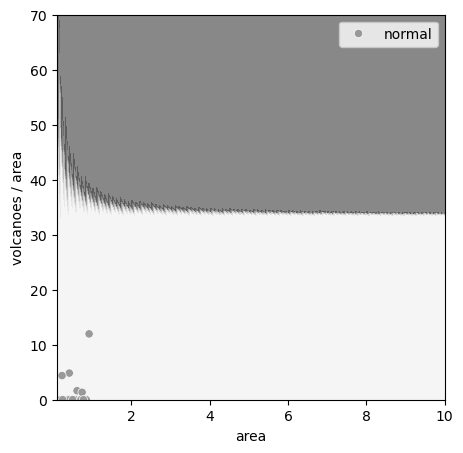

In [8]:
# 正常と異常の境界をプロット
import matplotlib.cm as cm
import seaborn as sns

# 描画用のFigureとAxesを生成
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(5, 5))

###### 正常と異常の範囲を色分け ######
# (t,x)格子点を作成
t_grid = np.linspace(0.1, 10, 100)
x_grid = np.arange(0, 700)
T, X = np.meshgrid(t_grid, x_grid)
X_grid = np.c_[T.ravel(), X.ravel()]
ratio_grid = X / T
# 下側しきい値（負の二項分布の累積分布関数から計算）
th_lowers = stats.nbinom.ppf(TARGET_FP_RATE/2, n=K, p=1/(1+THETA*X_grid[:, 0]))
# 上側しきい値（負の二項分布の累積分布関数から計算）
th_uppers = stats.nbinom.ppf(1 - TARGET_FP_RATE/2, n=K, p=1/(1+THETA*X_grid[:, 0]))
# しきい値判定
pred_grid = np.where((X_grid[:, 1] < th_lowers) | (X_grid[:, 1] > th_uppers),
                     0, 1)
# 正常と異常の境界をプロット
pred_pivot = pred_grid.reshape(T.shape)
ax.contourf(T, ratio_grid, pred_pivot,
            cmap=cm.gray, alpha=0.5)

###### 推論データを散布図としてプロット ######
sns.scatterplot(df_inference, x='area', y='volcanoes / area', hue='prediction',
                palette=['#999999', '#111111'], ax=ax)
ax.set_ylim(0, 70)
ax.legend()
# グラフを表示
plt.show()

正常と異常の境界は、どの推論データよりも遥に高い活火山密度（縦軸）に引かれていることがわかります。このような決定境界が引かれた原因を探るため、学習データを決定境界上に散布図でプロットしてみます。

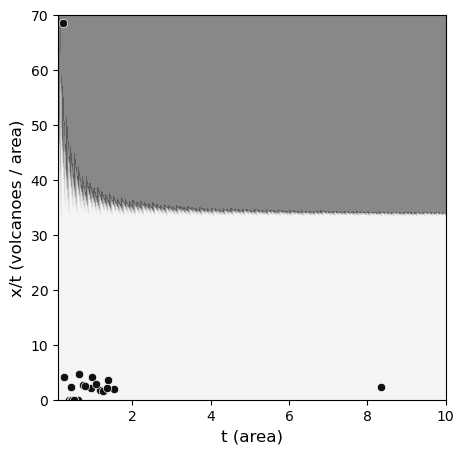

In [9]:
# 決定境界と重ねて学習データをプロット
# 決定境界プロット
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(5, 5))
ax.contourf(T, ratio_grid, pred_pivot,
            cmap=cm.gray, alpha=0.5)
# 学習データを散布図としてプロット
sns.scatterplot(x=t_train, y=x_train / t_train, c='#111111', ax=ax)
ax.set_xlabel('t (area)', fontsize=12)
ax.set_ylabel('x/t (volcanoes / area)', fontsize=12)
ax.set_ylim(0, 70)
# グラフを表示
plt.show()

左上の外れ値（東京都のデータ）が他のデータと比べて活火山密度が極端に高いため、この影響で高い活火山密度に決定境界が引かれたことがわかります（学習データから東京都のデータを抜くと、一気に過分散の影響がなくなり、むしろ未分散傾向となります）。

このようなサンプルサイズが小さいデータセットでの極端な外れ値は、過分散のモデリングに大きな影響を与えるため、モデリング時は外れ値検出と学習データへの追加/除外を慎重に検討する必要があります。